<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/A_Hybrid_CNN%E2%80%93EfficientNetB3_Attention_Framework_for_Binary_Arsenic_Skin_Disease_Classification_on_the_ArsenicSkinImagesBD_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

print("TensorFlow Version:", tf.__version__)
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

TensorFlow Version: 2.20.0


In [2]:
train_path = "/content/drive/MyDrive/ArsenicSkinImagesBD/Train"
test_path  = "/content/drive/MyDrive/ArsenicSkinImagesBD/Test"

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes

print(train_generator.class_indices)

Found 6659 images belonging to 2 classes.
Found 2233 images belonging to 2 classes.
{'infected': 0, 'not_infected': 1}


Hybrid CNN + EfficientNetB3 + Attention Model

In [6]:
input_layer = Input(shape=(224,224,3))

# CNN branch
x = Conv2D(
    32,
    3,
    activation='relu',
    padding='same'
)(input_layer)

x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(
    64,
    3,
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(
    128,
    3,
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

cnn_features = GlobalAveragePooling2D()(x)

In [7]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Fine-tune last 30 layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

y = base_model.output

y = GlobalAveragePooling2D()(y)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
attention = Dense(
    1536,
    activation='relu'
)(y)

attention = Dense(
    1536,
    activation='sigmoid'
)(attention)

attention_features = Multiply()(
    [y, attention]
)

In [9]:
combined = Concatenate()(
    [cnn_features, attention_features]
)

In [10]:
z = Dense(
    512,
    activation='relu'
)(combined)

z = BatchNormalization()(z)

z = Dense(
    256,
    activation='relu'
)(z)

z = Dropout(0.5)(z)

output = Dense(
    num_classes,
    activation='softmax',
    dtype='float32'
)(z)

In [11]:
model = Model(
    inputs=input_layer,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 16,585,713 (63.27 MB)

 Trainable params: 9,354,876 (35.69 MB)

 Non-trainable params: 7,230,837 (27.58 MB)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6843 - loss: 0.8665 

209/209 ━━━━━━━━━━━━━━━━━━━━ 3363s 16s/step - accuracy: 0.7322 - loss: 0.6783 - val_accuracy: 0.4953 - val_loss: 2.6045 - learning_rate: 0.0010
Epoch 2/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8171 - loss: 0.4238 

209/209 ━━━━━━━━━━━━━━━━━━━━ 3041s 15s/step - accuracy: 0.8210 - loss: 0.4160 - val_accuracy: 0.6767 - val_loss: 0.6054 - learning_rate: 0.0010
Epoch 3/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.8288 - loss: 0.3841 

209/209 ━━━━━━━━━━━━━━━━━━━━ 3120s 15s/step - accuracy: 0.8353 - loss: 0.3730 - val_accuracy: 0.6794 - val_loss: 0.7583 - learning_rate: 0.0010
Epoch 4/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 3110s 15s/step - accuracy: 0.8531 - loss: 0.3421 - val_accuracy: 0.5517 - val_loss: 1.1365 - learning_rate: 0.0010
Epoch 5/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 3079s 15s/step - accuracy: 0.8473 - loss: 0.3583 - val_accuracy: 0.4868 - val_loss: 1.1356 - learning_rate: 0.0010
Epoch 6/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8656 - loss: 0.3167 

209/209 ━━━━━━━━━━━━━━━━━━━━ 3053s 15s/step - accuracy: 0.8681 - loss: 0.3036 - val_accuracy: 0.6897 - val_loss: 0.5492 - learning_rate: 3.0000e-04
Epoch 7/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 3056s 15s/step - accuracy: 0.8871 - loss: 0.2753 - val_accuracy: 0.6176 - val_loss: 0.8992 - learning_rate: 3.0000e-04
Epoch 8/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8860 - loss: 0.2716 

209/209 ━━━━━━━━━━━━━━━━━━━━ 3068s 15s/step - accuracy: 0.8928 - loss: 0.2611 - val_accuracy: 0.7604 - val_loss: 0.5229 - learning_rate: 3.0000e-04
Epoch 9/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 3092s 15s/step - accuracy: 0.8919 - loss: 0.2579 - val_accuracy: 0.7447 - val_loss: 0.6034 - learning_rate: 3.0000e-04
Epoch 10/10
209/209 ━━━━━━━━━━━━━━━━━━━━ 3053s 15s/step - accuracy: 0.9051 - loss: 0.2339 - val_accuracy: 0.6126 - val_loss: 1.3784 - learning_rate: 3.0000e-04


In [15]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

70/70 ━━━━━━━━━━━━━━━━━━━━ 453s 6s/step - accuracy: 0.7604 - loss: 0.5229
Test Loss : 0.5229
Test Accuracy : 76.04 %


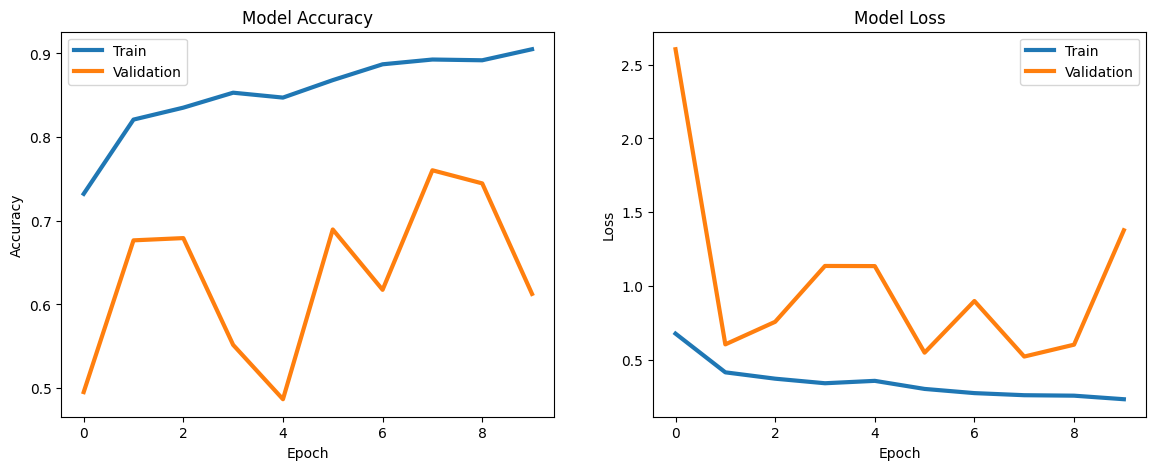

In [16]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], linewidth=3)
plt.plot(history.history['val_accuracy'], linewidth=3)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], linewidth=3)
plt.plot(history.history['val_loss'], linewidth=3)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [17]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

70/70 ━━━━━━━━━━━━━━━━━━━━ 467s 7s/step


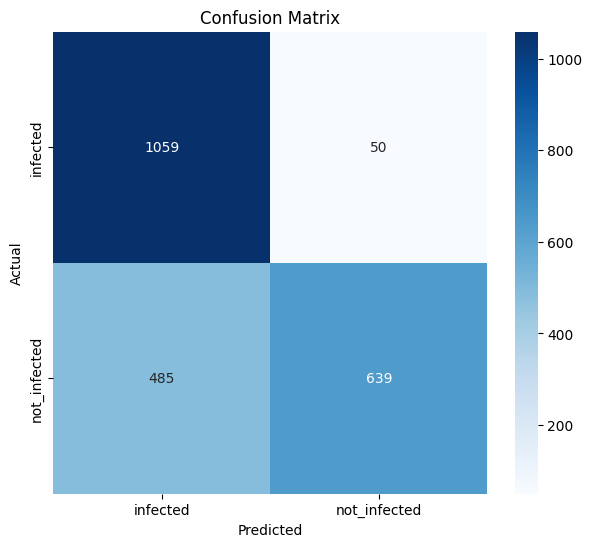

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    infected       0.69      0.95      0.80      1109
not_infected       0.93      0.57      0.70      1124

    accuracy                           0.76      2233
   macro avg       0.81      0.76      0.75      2233
weighted avg       0.81      0.76      0.75      2233



In [20]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :", round(precision*100,2), "%")
print("Recall    :", round(recall*100,2), "%")
print("F1 Score  :", round(f1*100,2), "%")

Precision : 80.75 %
Recall    : 76.04 %
F1 Score  : 75.13 %


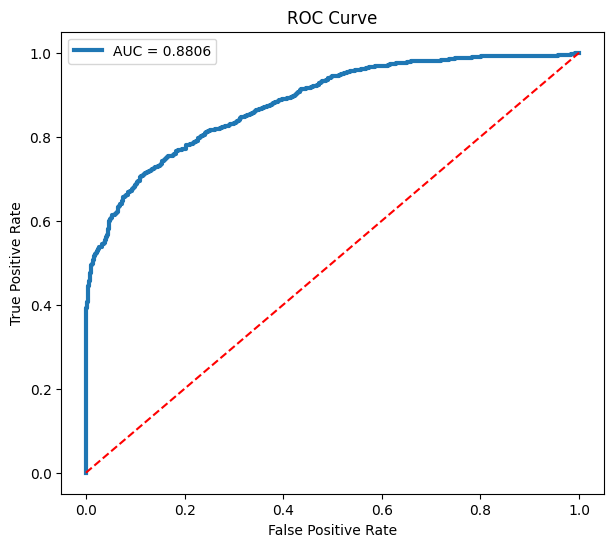

In [21]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_pred_prob[:,1]
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label='AUC = %0.4f' % roc_auc
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

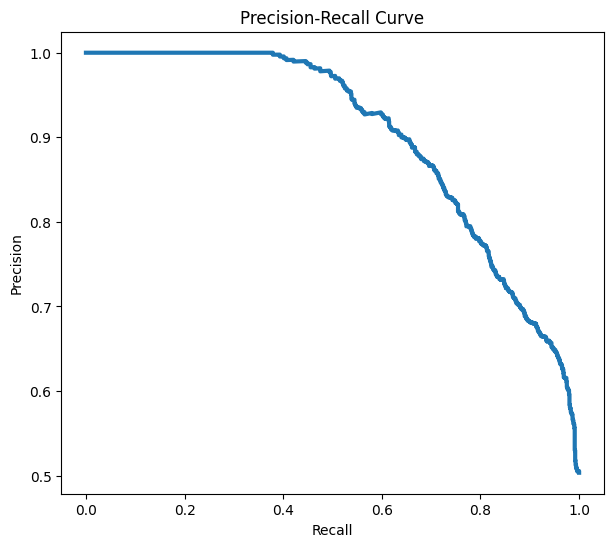

In [22]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_true,
    y_pred_prob[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=3
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

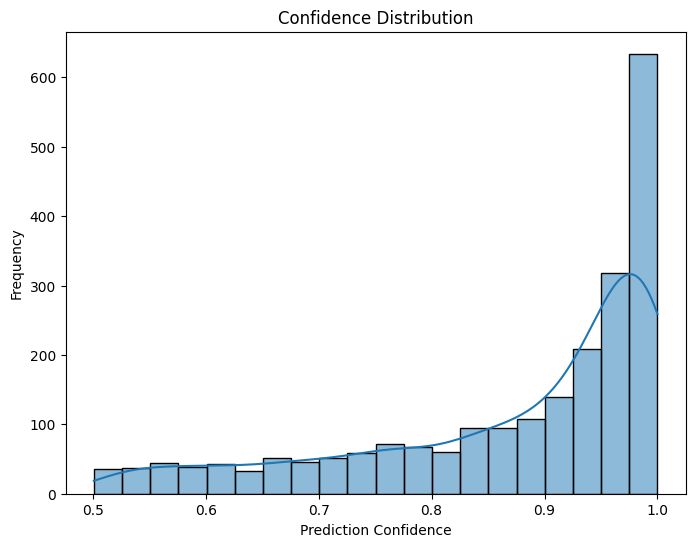

In [23]:
confidence = np.max(y_pred_prob, axis=1)

plt.figure(figsize=(8,6))

sns.histplot(
    confidence,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution")

plt.show()